In [1]:
DATASET_PATH = (
    "/lustre/fsn1/projects/rech/jmo/ubc65oh/datasets/mm_solar_panel_zarr_orbites2"
)
PATH_TRAINING = "/lustre/fsn1/projects/rech/jmo/ubc65oh/trainings/isprs_mm_sp_benchmark_v8/s2s1/fold_1/cd_mm_sits.layers.cosattention.TimeCosFormerAttention_True/2025-11-21/13-14-42-472942"  # /lustre/fsn1/projects/rech/jmo/ubc65oh/trainings/isprs_mm_sp_benchmark_v7/s2s1/fold_1/cd_mm_sits.layers.cosattention.TimeCosFormerAttention_True/2025-11-13/12-08-17-544969"

In [2]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from einops import rearrange
from hydra.utils import instantiate
from omegaconf import OmegaConf
from torchmetrics import MetricCollection

from cd_mm_sits.data.utils import from_int2date
from cd_mm_sits.lightning_module.mm_supervised_sp_detection import MMSupervisedSP
from cd_mm_sits.model.utils import cat_nested_along_time

/lustre/fswork/projects/rech/jmo/ubc65oh/code/cd_mm_sits/.pixi/envs/default/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_name = Path(PATH_TRAINING).parts[-3]

In [4]:
config_path = Path(PATH_TRAINING).joinpath(".hydra").joinpath("config.yaml")
# ckpt_path=get_best_checkpoint(Path(PATH_TRAINING),metric="best")
config = OmegaConf.load(config_path)

In [5]:
model = instantiate(config.model)
train_config = instantiate(
    config.train.train_config,
    metrics=MetricCollection(
        {name: instantiate(metric_cfg) for name, metric_cfg in config.metrics.items()}
    ),
)

In [6]:
ckpt_path = Path(PATH_TRAINING).joinpath(
    "lightning_logs/version_0/checkpoints/best.ckpt"
)
ckpt_path.exists()

True

In [7]:
# pl_module = SupervisedCD.load_from_checkpoint(PATH_CKPT,model=model, train_config=train_config)
pl_module = MMSupervisedSP(model=model, train_config=train_config)
pl_module = MMSupervisedSP.load_from_checkpoint(
    ckpt_path, model=model, train_config=train_config, strict=False
)
# pl_module.model.load_state_dict(torch.load(ckpt_path, weights_only=True,map_location=torch.device('cpu')))()
pl_module.freeze()
pl_module.eval()
datamodule = instantiate(config.datamodule, num_workers=4)
datamodule.setup("test")

In [8]:
test_dataloader = datamodule.test_dataloader()
iter_dataloader = iter(test_dataloader)

/lustre/fswork/projects/rech/jmo/ubc65oh/code/cd_mm_sits/.pixi/envs/default/lib/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [9]:
import numpy as np
import torch.nn as nn
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap


class CustomNorm(BoundaryNorm):
    def __init__(self, boundaries):
        boundaries = [-1.5, -0.5] + list(np.linspace(0, 1, 256))
        super().__init__(boundaries, ncolors=len(boundaries) - 1)


def show_results_mm(batch, out, idx_sort, mm_times, band_s1=0, figsize=(70, 5)):
    s1_len = batch.s1.time[0, ...].shape[0]
    pred = nn.functional.sigmoid(out).cpu()
    # pred=outputs.out
    # label = outputs.label.cpu()
    len_T = idx_sort.shape[0]
    fig, ax = plt.subplots(3, len_T, figsize=figsize)
    cmap = ListedColormap(["gray", "black", "red"])
    bounds = [-1.5, -0.5, 0.5, 1.5]
    colors = [
        (0.0, "black"),  # 0
        (0.5, "white"),  # 0.5
        (1.0, "red"),  # 1
    ]
    custom_cmap = LinearSegmentedColormap.from_list("black_white_red", colors)
    norm = BoundaryNorm(bounds, cmap.N)
    full_colors = ["gray"] + [custom_cmap(i / 255) for i in range(256)]
    full_cmap = ListedColormap(full_colors)
    boundaries = [-1.5, -0.5] + list(np.linspace(0, 1, 256))
    norm2 = CustomNorm(boundaries=boundaries)
    for t, idx_img in enumerate(idx_sort):
        # print(idx_img,s1_len)
        ax[0, t].set_title(str(from_int2date(mm_times[0, idx_img].item()).date()))
        if int(idx_img) >= s1_len:
            ax[0, t].imshow(
                rearrange(
                    batch.s2.sits[0, idx_img - s1_len, [0, 1, 2], ...] / 5000,
                    "c h w -> h w c",
                )
            )
            label = batch.s2.label[0, idx_img - s1_len, ...]
            label[~batch.mask_site.bool()[0, ...]] = -1
            ax[1, t].imshow(label, norm=norm, cmap=cmap)
            pred_show = pred[0, t, ...]
            pred_show[~batch.mask_site.bool()[0, ...]] = -1
            ax[2, t].imshow(pred[0, t, ...], norm=norm2, cmap=full_cmap)
        else:
            ax[0, t].set_title(str(from_int2date(mm_times[0, idx_img].item()).date()))
            ax[0, t].imshow(batch.s1.sits[0, idx_img, band_s1, ...])
            # ax[2,t].imshow(pred[0,idx_img,...],norm=norm2,cmap=full_cmap)
        # ax[1,t].imshow(label[0,t,...],norm=norm,cmap=cmap)
        ax[0, t].set_axis_off()
        ax[1, t].set_axis_off()
        ax[2, t].set_axis_off()
    return fig

In [10]:
for i in range(10):
    batch = next(iter_dataloader)

torch.Size([16])


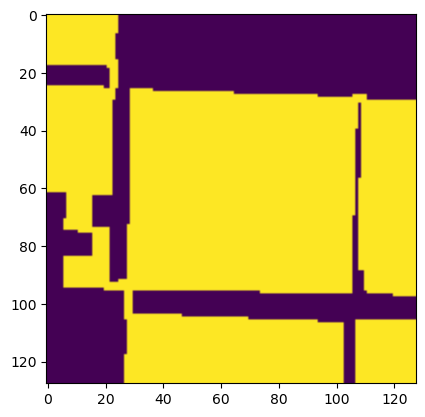

In [49]:
batch = next(iter_dataloader)
plt.imshow(batch.mask_site[0, ...], vmin=0, vmax=1)
print(batch.s2.time[0, ...].shape)

In [50]:
copy_batch = copy.deepcopy(batch)
norm_batch = datamodule.on_after_batch_transfer(batch, 0)
out, sorted_idx, weight = pl_module(norm_batch, need_weights=True)
mm_times = cat_nested_along_time(batch.s1.time, batch.s2.time)
idx = torch.argsort(mm_times[0, ...], dim=-1)  # B,T
s1_len = batch.s1.time[0, ...].shape[0]
s2_len = batch.s2.time.shape[1]

In [51]:
print(mm_times[0, ...].shape[0])

32


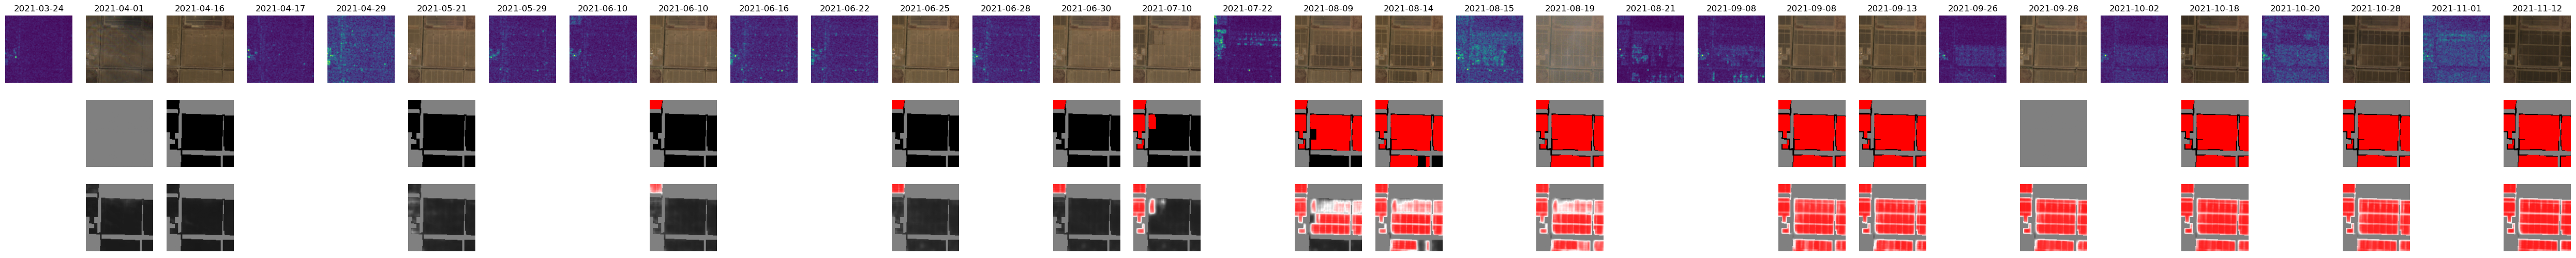

In [52]:
fig = show_results_mm(
    copy_batch, out, idx, mm_times, 0, figsize=(mm_times[0, ...].shape[0] * 2, 6)
)

In [53]:
# fig.tight_layout()
fig.savefig(f"fixed_res_isprs_{model_name}.pdf")

In [ ]:
fig.tight_layout()
fig

In [ ]:
weight[0].shape

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(3, weight[0].shape[1], figsize=(30, 10))
for l in range(3):
    for h in range(weight[0].shape[1]):
        attn_mean = torch.mean(weight[l][:, h, ...], dim=0)
        sns.heatmap(attn_mean, ax=ax[l, h], robust=True)
        ax[l, h].grid(False)
# fig

In [ ]:
fig.savefig(f"mm_attn_{model_name}.pdf")

In [ ]:
fig.tight_layout()
fig